PLots para poucas fontes Electrons


=== PLOTTING ELECTRON GRAPHS ===


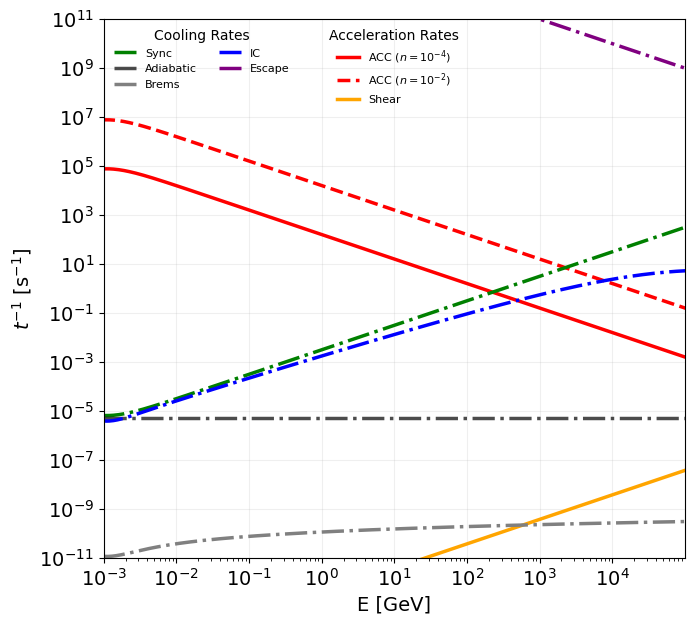

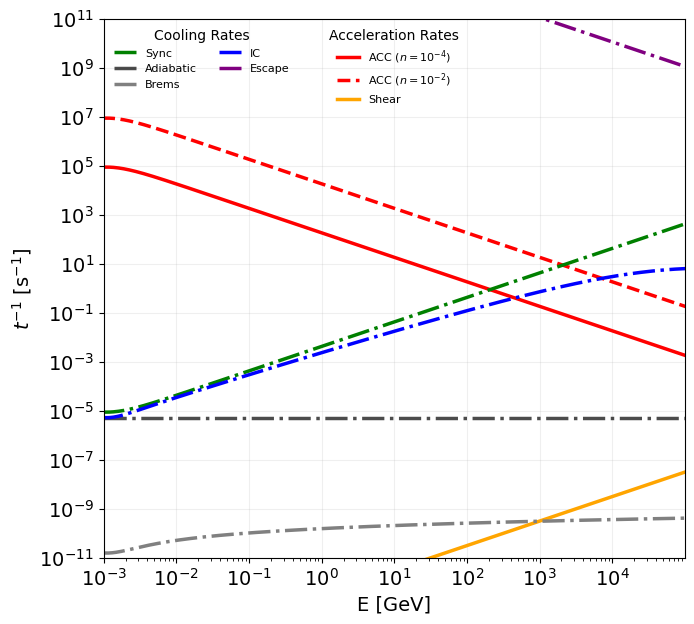

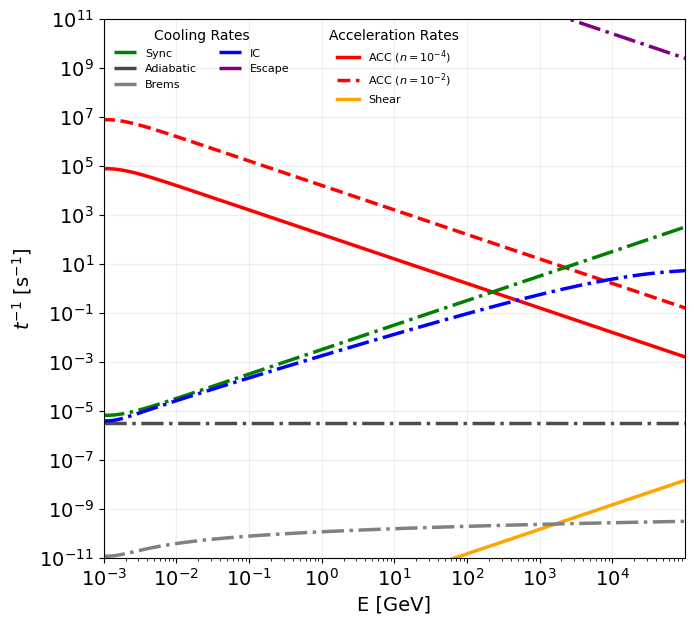

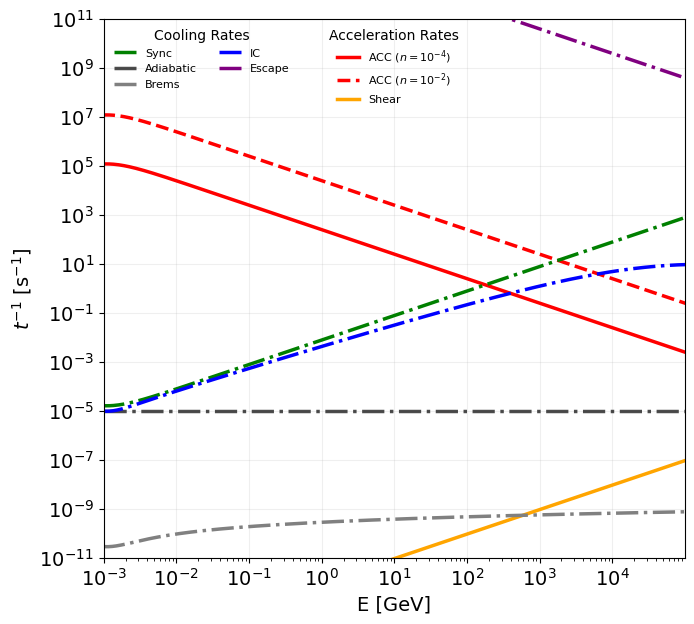

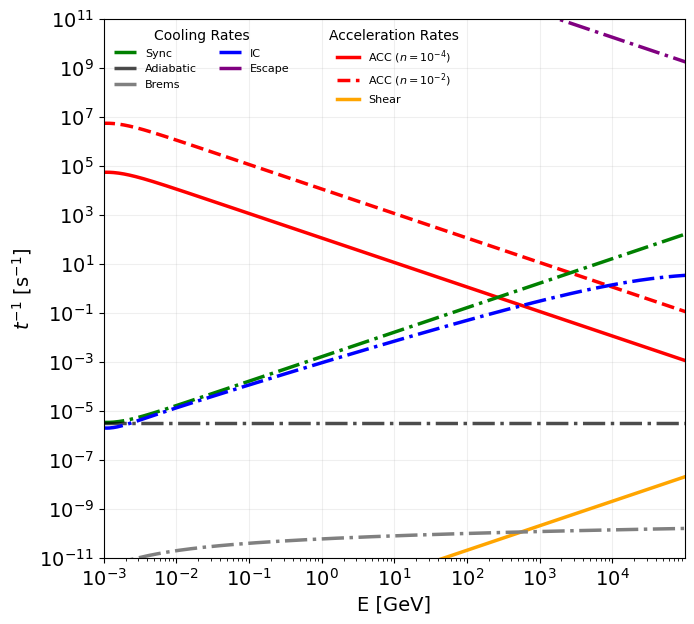

...

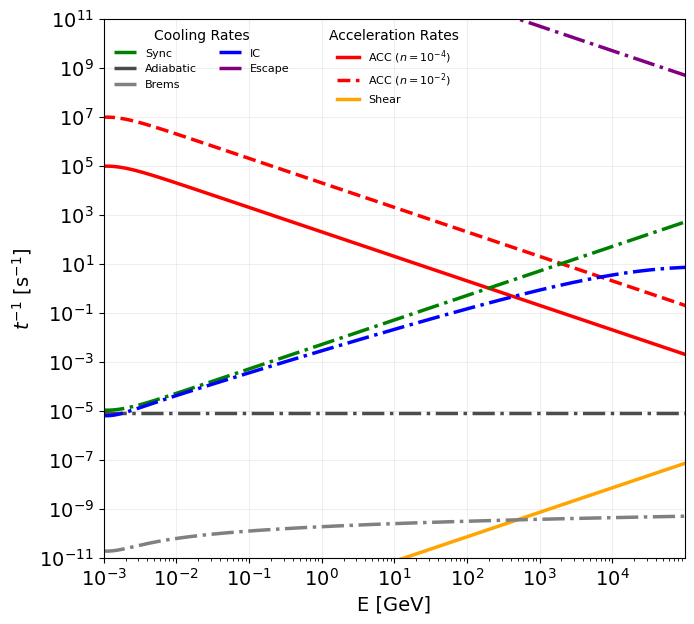

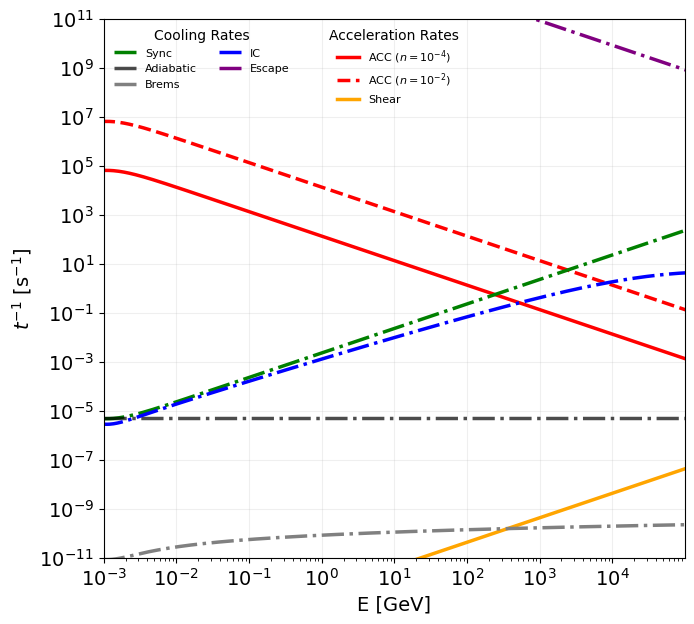

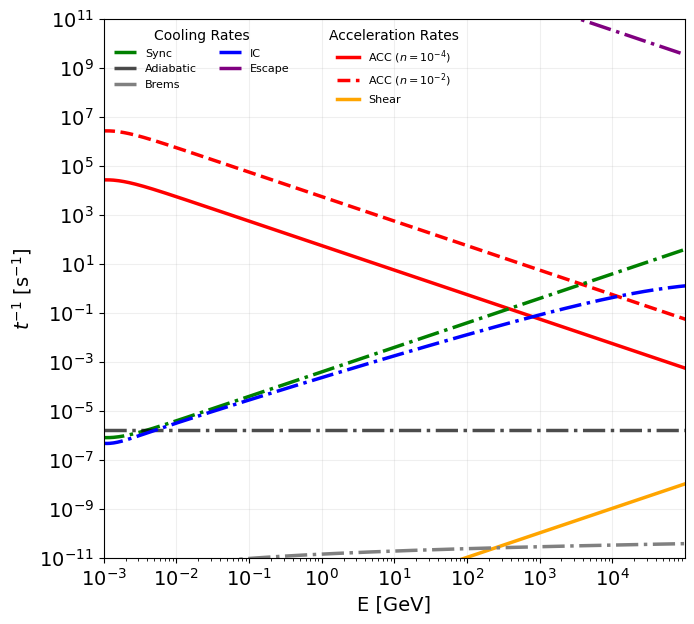

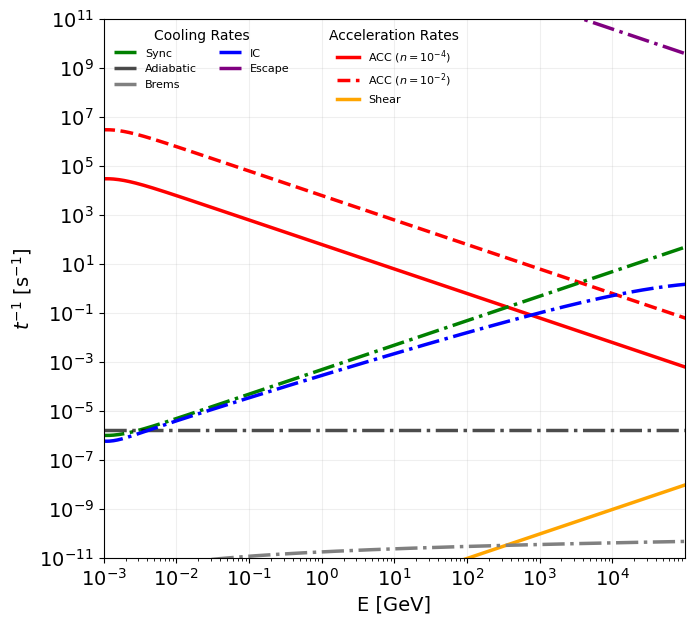

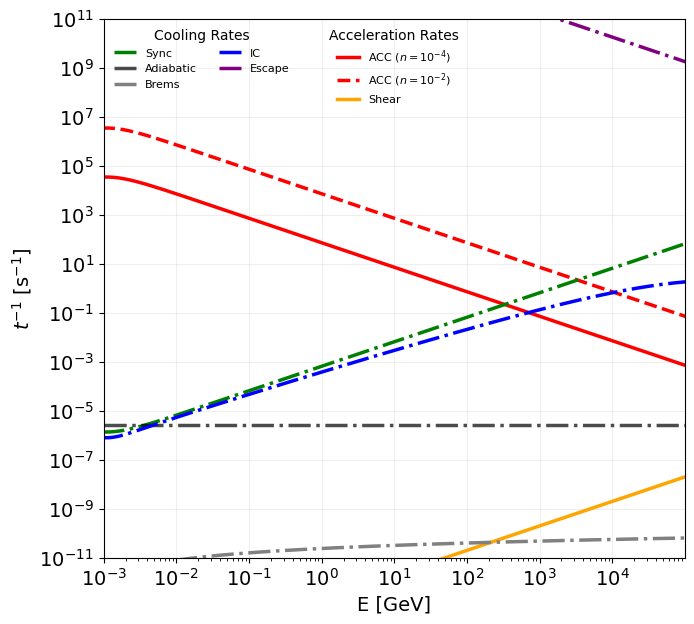

In [16]:
print("=== PLOTTING ELECTRON GRAPHS ===")
import csv
import matplotlib.pyplot as plt
import os

source_file = "source.txt"
source_list = []

try:
    with open(source_file, mode='r') as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            source_list.append(row)
except FileNotFoundError:
    print(f"ERROR: File '{source_file}' not found.")

for params in source_list:
    source_name = params['name']
    filename = f"data/{source_name}_electrons.csv"
    
    # 1. Resgatando os valores de n do seu source.txt
    # Usamos o .get() com um valor padrão para evitar que o código quebre 
    # caso alguma linha antiga do txt não tenha o n_2 ainda.
    n_val = params.get('n', 'N/A')
    n_2_val = params.get('n_2', 'N/A')
    
    E_GeV_ele, rate_acc, rate_acc_2, rate_sync, rate_bremss, rate_ic0, rate_ic1 = [], [], [], [], [], [], []
    rate_shear_ele, rate_esc_ele = [], [] 
    t_ad_val = 0
    
    try:
        with open(filename, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                E_GeV_ele.append(float(row['E_GeV']))
                rate_acc.append(float(row['rate_acc']))
                rate_acc_2.append(float(row['rate_acc_2']))
                rate_sync.append(float(row['rate_sync']))
                rate_bremss.append(float(row['rate_bremss']))
                rate_ic0.append(float(row['rate_ic_0']))
                rate_ic1.append(float(row['rate_ic_1']))
                rate_shear_ele.append(float(row['Shear'])) 
                rate_esc_ele.append(float(row['ESC']))     
                t_ad_val = float(row['t_ad_val']) 
    except FileNotFoundError:
        print(f"ERROR: File '{filename}' not found.")
        continue

    plt.figure(figsize=(7.5, 7))

    # 2. Inserindo os valores dinamicamente nas labels usando f-strings
    # O Matplotlib entende o $...$ para renderizar a fonte matemática bonitinha
    line_acc, = plt.loglog(E_GeV_ele, rate_acc, label=r'ACC ($n=10^{-4}$)', color='red', linestyle='-', linewidth=2.5)
    line_acc2, = plt.loglog(E_GeV_ele, rate_acc_2, label=r'ACC ($n=10^{-2}$)', color='red', linestyle='--', linewidth=2.5)
    
    line_shear, = plt.loglog(E_GeV_ele, rate_shear_ele, label='Shear', color='orange', linestyle='-', linewidth=2.5)
    
    # Curvas de Resfriamento/Fuga
    line_sync, = plt.loglog(E_GeV_ele, rate_sync, label='Sync', color='green', linestyle='dashdot', linewidth=2.5)
    line_ad = plt.axhline(y=t_ad_val, label='Adiabatic', color='black', linestyle='dashdot', alpha=0.7, linewidth=2.5)
    line_brems, = plt.loglog(E_GeV_ele, rate_bremss, label='Brems', color='grey', linestyle='dashdot', linewidth=2.5)
    line_ic1, = plt.loglog(E_GeV_ele, rate_ic1, label='IC', color='blue', linestyle='dashdot', markerfacecolor='none', linewidth=2.5)
    line_esc, = plt.loglog(E_GeV_ele, rate_esc_ele, label='Escape', color='purple', linestyle='dashdot', linewidth=2.5)
    
    # Atualização da legenda
    leg_acc = plt.legend(handles=[line_acc, line_acc2, line_shear], title='Acceleration Rates', loc='upper center', fontsize=8, frameon=False)
    plt.gca().add_artist(leg_acc) 
    leg_cool = plt.legend(handles=[line_sync, line_ad, line_brems, line_ic1, line_esc], title='Cooling Rates', loc='upper left', fontsize=8, frameon=False, ncol=2)
    
    plt.xlabel('E [GeV]', fontsize=14)
    plt.ylabel('$t^{-1}$ [s$^{-1}$]', fontsize=14)
    plt.xlim(1e-3, 1e5)
    plt.ylim(1e-11, 1e11)
    
    plt.xticks([10.0**i for i in range(-3, 5, 1)])
    plt.yticks([10.0**i for i in range(-11, 12, 2)])
    plt.tick_params(axis='both', which='major', labelsize=14)
        
    plt.grid(True, which="major", ls="-", alpha=0.2)
    
    os.makedirs("image", exist_ok=True)
    
    plt.savefig(f"image/{source_name}_electrons.png", bbox_inches='tight')
    plt.show()

PLots para poucas fontes Protons


=== PLOTTING PROTON GRAPHS ===


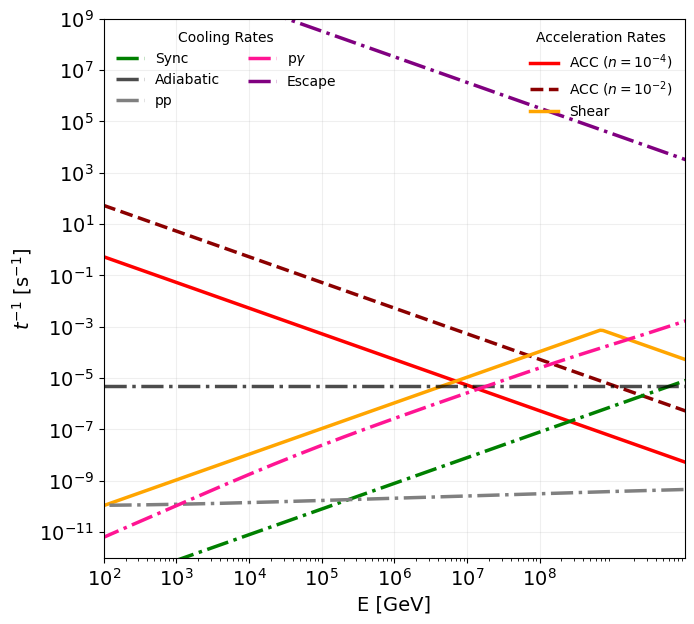

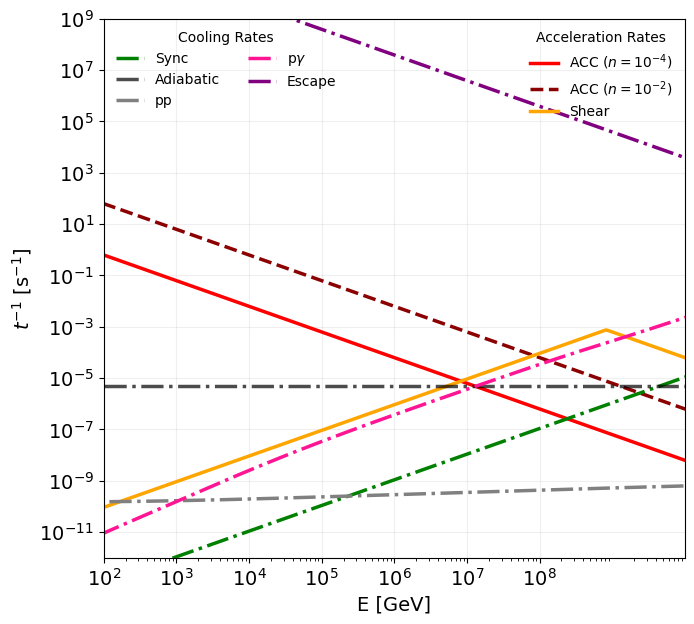

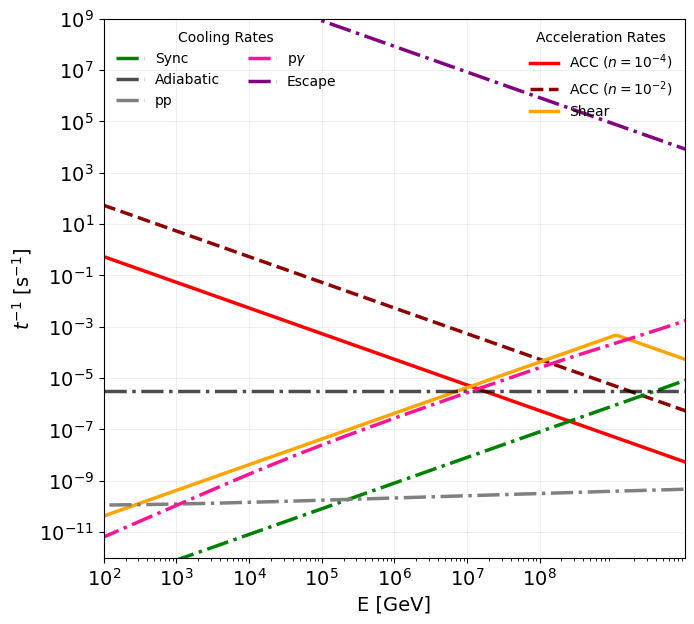

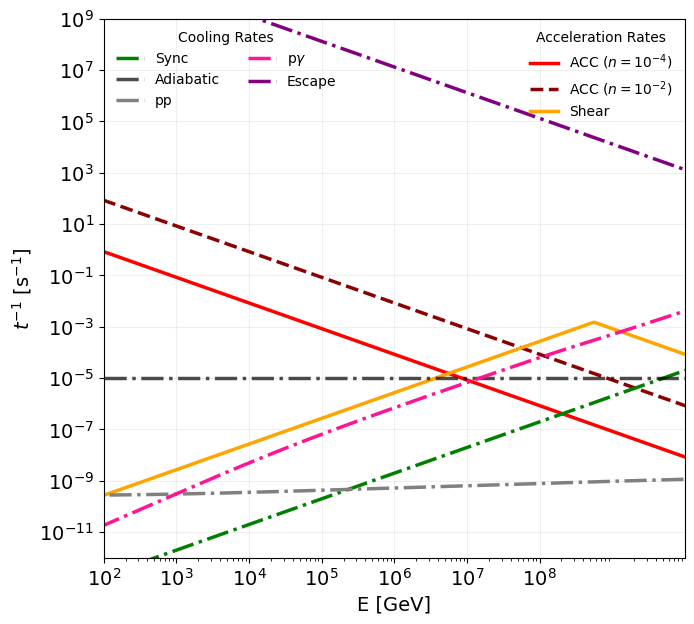

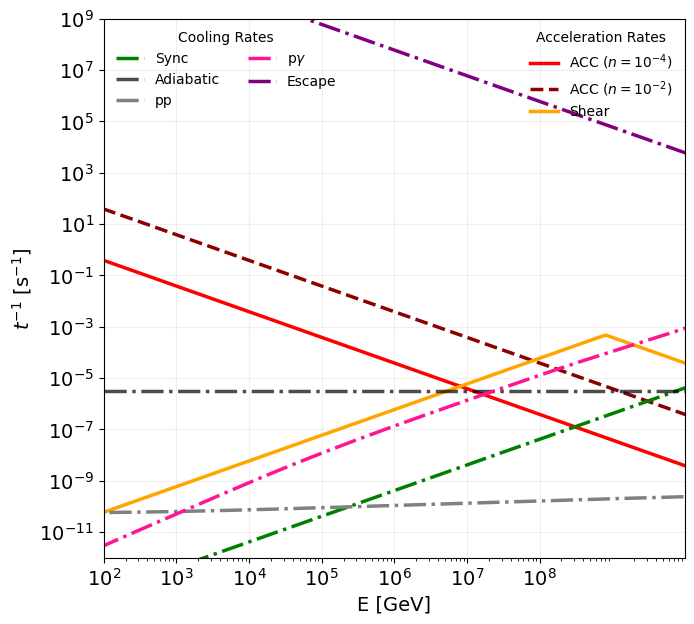

...

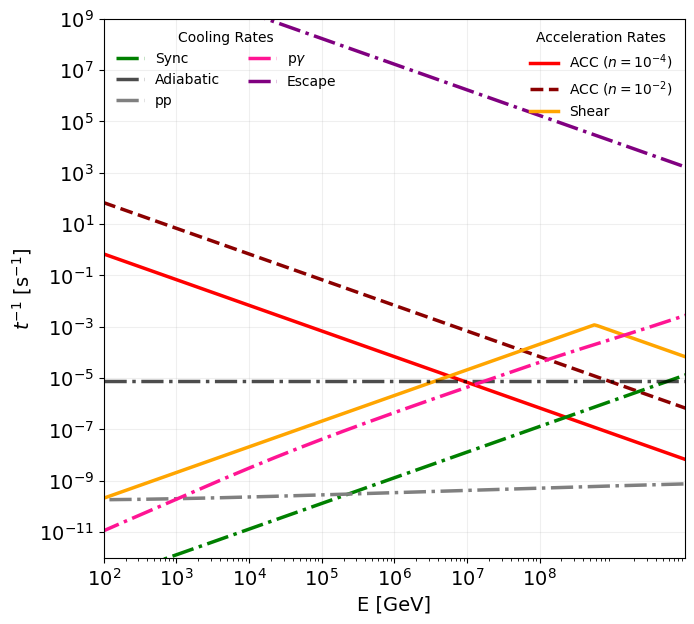

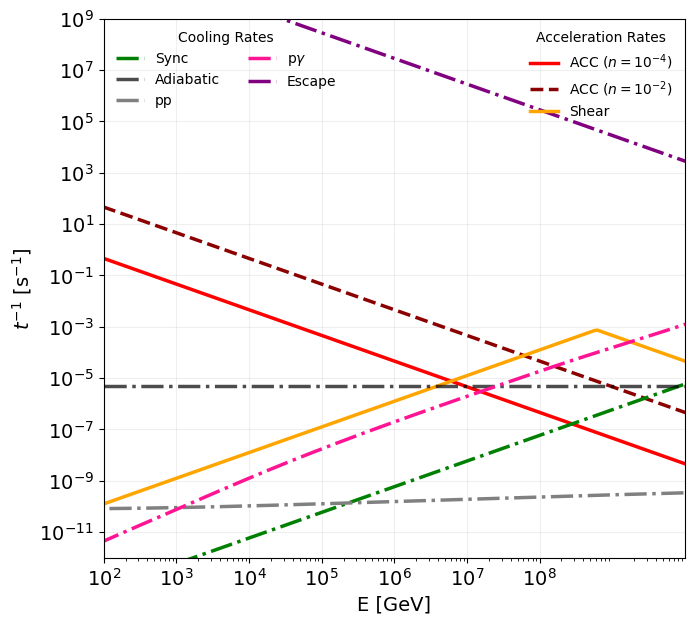

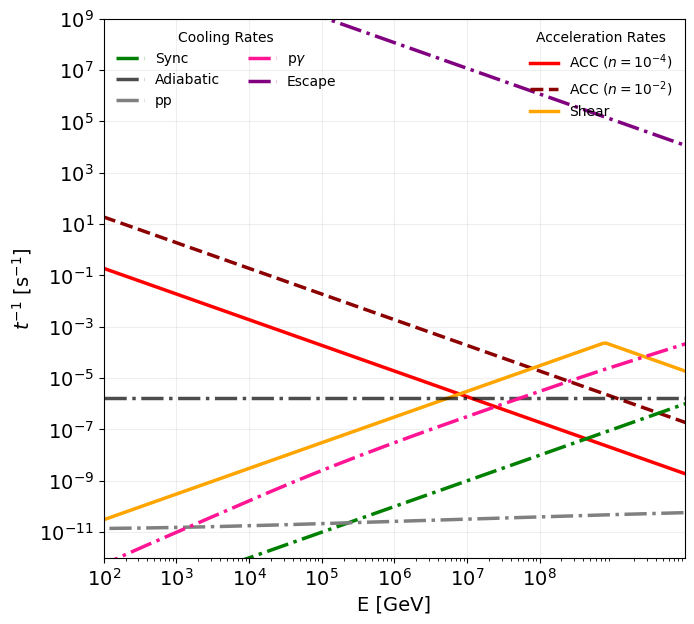

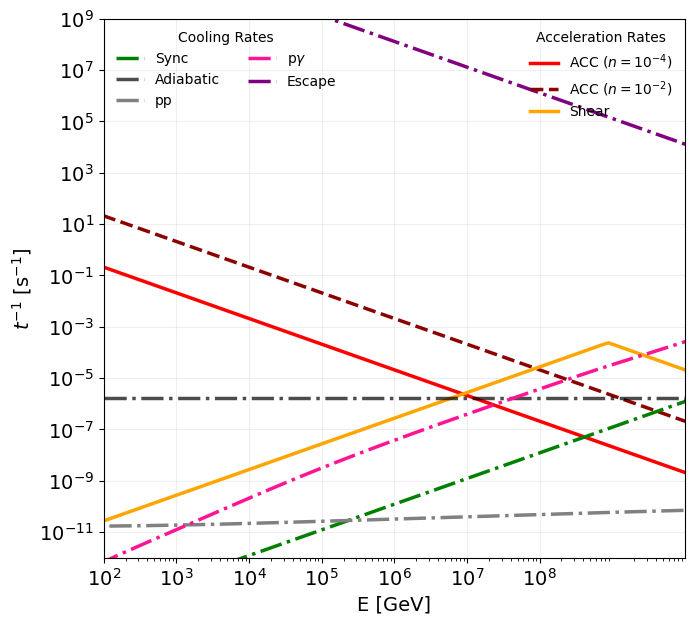

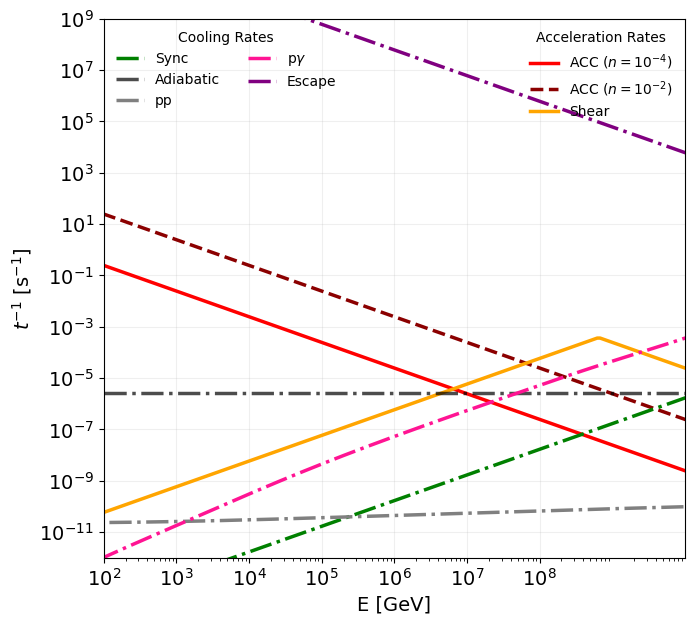

In [17]:
print("=== PLOTTING PROTON GRAPHS ===")
import csv
import matplotlib.pyplot as plt
import os

# Garante que a pasta existe para não dar erro no savefig
os.makedirs("image", exist_ok=True)

for params in source_list:
    source_name = params['name']
    filename = f"data/{source_name}_protons.csv"
    
    # 1. Resgatando os valores de n para as legendas
    n_val = params.get('n', 'N/A')
    n_2_val = params.get('n_2', 'N/A')
    
    # 2. Inicializando a nova lista rate_acc_pro_2
    E_GeV_pro, rate_acc_pro, rate_acc_pro_2, rate_sync_pro, rate_pp, rate_pg = [], [], [], [], [], []
    rate_shear_pro, rate_esc_pro = [], [] 
    t_ad_val = 0
    
    try:
        with open(filename, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                E_GeV_pro.append(float(row['E_prime_GeV']))
                rate_acc_pro.append(float(row['rate_acc']))
                
                # 3. Lendo a nova taxa de aceleração do CSV
                rate_acc_pro_2.append(float(row['rate_acc_2']))
                
                rate_sync_pro.append(float(row['rate_sync']))
                rate_pp.append(float(row['rate_pp']))
                rate_pg.append(float(row['rate_pg']))
                rate_shear_pro.append(float(row['Shear'])) 
                rate_esc_pro.append(float(row['ESC']))     
                t_ad_val = float(row['t_ad_val'])
                
        plt.figure(figsize=(7.5, 7))
        
        # 4. Curvas de Aceleração (Original e Alternativa) com f-strings
        line_acc, = plt.loglog(E_GeV_pro, rate_acc_pro, label=r'ACC ($n=10^{-4}$)', color='red', linestyle='-', linewidth=2.5)
        line_acc2, = plt.loglog(E_GeV_pro, rate_acc_pro_2, label=r'ACC ($n=10^{-2}$)', color='darkred', linestyle='--', linewidth=2.5)
        line_shear, = plt.loglog(E_GeV_pro, rate_shear_pro, label='Shear', color='orange', linestyle='-', linewidth=2.5)
        
        # Curvas de Resfriamento/Fuga
        line_sync, = plt.loglog(E_GeV_pro, rate_sync_pro, label='Sync', color='green', linestyle='-.', linewidth=2.5)
        line_ad = plt.axhline(y=t_ad_val, label='Adiabatic', color='black', linestyle='-.', alpha=0.7, linewidth=2.5)
        line_pp, = plt.loglog(E_GeV_pro, rate_pp, label='pp', color='grey', linestyle='-.', linewidth=2.5)
        line_pg, = plt.loglog(E_GeV_pro, rate_pg, label='p$\gamma$', color='deeppink', linestyle='-.', linewidth=2.5)
        line_esc, = plt.loglog(E_GeV_pro, rate_esc_pro, label='Escape', color='purple', linestyle='-.', linewidth=2.5)

        # 5. Atualização da legenda de aceleração incluindo line_acc2
        leg_acc = plt.legend(handles=[line_acc, line_acc2, line_shear], title='Acceleration Rates', loc='upper right', fontsize=10, frameon=False)
        plt.gca().add_artist(leg_acc) 
        leg_cool = plt.legend(handles=[line_sync, line_ad, line_pp, line_pg, line_esc], title='Cooling Rates', loc='upper left', fontsize=10, frameon=False, ncol=2)

        plt.xlabel('E [GeV]', fontsize=14)
        plt.ylabel('$t^{-1}$ [s$^{-1}$]', fontsize=14)
        plt.xlim(1e2, 1e10)
        plt.ylim(1e-12, 1e9)
        
        plt.xticks([10.0**i for i in range(2, 9, 1)])
        plt.yticks([10.0**i for i in range(-11, 10, 2)])
        plt.tick_params(axis='both', which='major', labelsize=14)
            
        plt.grid(True, which="major", ls="-", alpha=0.2)
        
        # O bbox_inches='tight' evita que a legenda fique cortada ao salvar
        plt.savefig(f"image/{source_name}_protons.png", bbox_inches='tight')
        plt.show()
        
    except FileNotFoundError:
        print(f"File {filename} not found for plotting.")

Para poucas fontes plt geral

In [ ]:
import matplotlib.pyplot as plt
import csv
import os
import glob
import matplotlib.cm as cm

print("=== PLOTTING POPULATION (100+ SOURCES WITH EXTERNAL LEGEND) ===")

# ======================================================================
# 1. CONFIGURAÇÃO DOS PROCESSOS
# ======================================================================
config_ele = {
    'acc_n':   {'xlim': (1e-3, 1e5), 'ylim': (1e0, 1e8), 'csv_col': 'rate_acc'}, 
    'acc_n2':  {'xlim': (1e-3, 1e5), 'ylim': (1e0, 1e8), 'csv_col': 'rate_acc_2'},
    'sync':    {'xlim': (1e-2, 1e2), 'ylim': (1e-4, 1e0), 'csv_col': 'rate_sync'},
    'brems':   {'xlim': (1e-3, 1e5), 'ylim': (1e-11, 1e-9),'csv_col': 'rate_bremss'},
    'ic':      {'xlim': (1e-3, 1e5), 'ylim': (1e-7, 1e2), 'csv_col': 'rate_ic_1'},
    'shear':   {'xlim': (1e0, 1e5),  'ylim': (1e-12, 1e-8),'csv_col': 'Shear'},
    'esc':     {'xlim': (1e3, 1e6),  'ylim': (1e8, 1e11), 'csv_col': 'ESC'}
}

config_pro = {
    'acc_n':   {'xlim': (5e0, 1e5),  'ylim': (1e-3, 1e3), 'csv_col': 'rate_acc'},
    'acc_n2':  {'xlim': (5e0, 1e5),  'ylim': (1e-3, 1e3), 'csv_col': 'rate_acc_2'},
    'sync':    {'xlim': (1e3, 1e8),  'ylim': (1e-11, 1e-8),'csv_col': 'rate_sync'},
    'pp':      {'xlim': (5e0, 1e9),  'ylim': (1e-11, 1e-8),'csv_col': 'rate_pp'},
    'pg':      {'xlim': (1e6, 1e9),  'ylim': (1e-8, 1e-1),'csv_col': 'rate_pg'},
    'shear':   {'xlim': (1e1, 1e6),  'ylim': (1e-12, 1e-8),'csv_col': 'Shear'},
    'esc':     {'xlim': (1e4, 1e7),  'ylim': (1e7, 1e10), 'csv_col': 'ESC'}
}

def process_and_plot_population(particle_type, config_processos, e_col_name):
    padrao = f"data3/*_{particle_type}.csv"
    arquivos = glob.glob(padrao)
    
    if not arquivos:
        print(f"Nenhum arquivo encontrado para {particle_type} na pasta 'data3/'.")
        return
        
    print(f"[{particle_type.upper()}] Encontradas {len(arquivos)} fontes. Iniciando leitura...")

    master_data = {}
    
    # ======================================================================
    # 2. LER TODOS OS ARQUIVOS COM DIAGNÓSTICO DE ERROS
    # ======================================================================
    for filepath in arquivos:
        nome_arquivo = os.path.basename(filepath)
        base_name = nome_arquivo.replace(f"_{particle_type}.csv", "")
        
        master_data[base_name] = {'E': []}
        for key in config_processos.keys():
            master_data[base_name][key] = []
            
        with open(filepath, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            cabecalhos = reader.fieldnames
            
            # 1. Verifica se a coluna de Energia existe no arquivo
            if cabecalhos is None or e_col_name not in cabecalhos:
                print(f"  -> ERRO CRÍTICO: Coluna de energia '{e_col_name}' não existe em {nome_arquivo}!")
                continue # Pula este arquivo inteiro
            
            # 2. Verifica quais colunas de processos realmente existem neste CSV
            processos_validos = []
            for proc_key, p_conf in config_processos.items():
                col_name = p_conf['csv_col']
                if col_name in cabecalhos:
                    processos_validos.append(proc_key)
                else:
                    # Avisa na tela qual coluna está faltando e com qual nome ele procurou
                    print(f"  -> AVISO: Coluna '{col_name}' faltando no arquivo {nome_arquivo}. Processo '{proc_key}' não será plotado para esta fonte.")

            # 3. Lê as linhas garantindo que E e t^-1 tenham o mesmo tamanho
            for row in reader:
                try:
                    e_val = float(row[e_col_name])
                    
                    # Lê os valores temporariamente para garantir que não vai dar erro
                    temp_vals = {}
                    for proc_key in processos_validos:
                        col_name = config_processos[proc_key]['csv_col']
                        temp_vals[proc_key] = float(row[col_name])
                    
                    # Se chegou até aqui sem dar erro (sem encontrar strings vazias), salva nas listas finais
                    master_data[base_name]['E'].append(e_val)
                    for proc_key in processos_validos:
                        master_data[base_name][proc_key].append(temp_vals[proc_key])
                        
                except ValueError:
                    # Pula silenciosamente apenas linhas com texto/espaços vazios no meio dos números
                    pass 

    os.makedirs("image", exist_ok=True)
    import matplotlib.cm as cm
    cmap = cm.get_cmap('tab20')
    cores = cmap.colors

    # ======================================================================
    # 3. PLOTAR OS GRÁFICOS
    # ======================================================================
    for proc_key, p_config in config_processos.items():
        plt.figure(figsize=(14, 7))
        
        fontes_validas = 0
        for i, (base_name, dados) in enumerate(master_data.items()):
            # Só plota se tiver dados de energia E dados daquele processo específico
            if not dados['E'] or not dados[proc_key]:
                continue
            
            cor_atual = cores[i % len(cores)]
            
            plt.loglog(dados['E'], dados[proc_key], color=cor_atual, alpha=0.6, 
                       linewidth=1.2, label=base_name)
            fontes_validas += 1
            
        # Se nenhuma fonte teve dados para este processo, avisa e não salva gráfico em branco
        if fontes_validas == 0:
            print(f"  -> {proc_key}: Nenhuma fonte plotada (verifique os avisos de colunas faltando acima).")
            plt.close()
            continue

        xlabel_str = 'E [GeV]' if particle_type == 'electrons' else r'$E^\prime$ [GeV]'
        plt.xlabel(xlabel_str, fontsize=16)
        plt.ylabel(r'$t^{-1}$ [s$^{-1}$]', fontsize=16)
        
        plt.xlim(p_config['xlim'])
        plt.ylim(p_config['ylim'])
        plt.tick_params(axis='both', which='major', labelsize=16)
        plt.grid(True, which="major", ls="-", alpha=0.2)
        
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', 
                   fontsize=6, ncol=4, frameon=False, title="Fontes",)
        
        plt.subplots_adjust(right=0.6) 
        
        nome_arquivo = f"image/{particle_type.capitalize()}_{proc_key}_population.png"
        plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
        print(f"  -> Salvo: {nome_arquivo} ({fontes_validas} linhas plotadas)")

process_and_plot_population(particle_type='electrons', config_processos=config_ele, e_col_name='E_GeV')
process_and_plot_population(particle_type='protons', config_processos=config_pro, e_col_name='E_prime_GeV')

Plot geral das fontes

In [ ]:
import matplotlib.pyplot as plt
import csv
import os
import glob
import matplotlib.cm as cm
import math

print("=== PLOTTING COMBINED FIGURE FOR POPULATION ===")

# ======================================================================
# 1. CONFIGURAÇÃO DOS PROCESSOS (7 Processos no total)
# ======================================================================
config_ele = {
    'acc_n':   {'title': 'Acceleration Rate (n)',  'xlim': (1e-3, 1e5), 'ylim': (1e0, 1e8),   'csv_col': 'rate_acc'}, 
    'acc_n2':  {'title': 'Acceleration Rate (n2)', 'xlim': (1e-3, 1e5), 'ylim': (1e0, 1e8),   'csv_col': 'rate_acc_2'},
    'sync':    {'title': 'Synchrotron Cooling',    'xlim': (1e-3, 1e1), 'ylim': (1e-3, 1e1),  'csv_col': 'rate_sync'},
    'brems':   {'title': 'Bremsstrahlung Cooling', 'xlim': (1e-3, 1e5), 'ylim': (1e-9, 1e-6), 'csv_col': 'rate_bremss'},
    'ic':      {'title': 'Inverse Compton Cooling','xlim': (1e-3, 1e5), 'ylim': (1e-7, 1e2),  'csv_col': 'rate_ic_1'},
    'shear':   {'title': 'Shear Acceleration',     'xlim': (1e0, 1e5),  'ylim': (1e-12, 1e-8),'csv_col': 'Shear'},
    'esc':     {'title': 'Escape Rate',            'xlim': (1e3, 1e6),  'ylim': (1e8, 1e11),  'csv_col': 'ESC'}
}

config_pro = {
    'acc_n':   {'title': 'Acceleration Rate (n)',  'xlim': (5e0, 1e5),  'ylim': (1e-3, 1e3),  'csv_col': 'rate_acc'},
    'acc_n2':  {'title': 'Acceleration Rate (n2)', 'xlim': (5e0, 1e5),  'ylim': (1e-3, 1e3),  'csv_col': 'rate_acc_2'},
    'sync':    {'title': 'Synchrotron Cooling',    'xlim': (1e1, 1e6),  'ylim': (1e-11, 1e-8),'csv_col': 'rate_sync'},
    'pp':      {'title': 'PP Collision Rate',      'xlim': (5e0, 1e9),  'ylim': (1e-9, 1e-6), 'csv_col': 'rate_pp'},
    'pg':      {'title': r'P$\gamma$ Cooling',     'xlim': (1e6, 1e9),  'ylim': (1e-8, 1e-1), 'csv_col': 'rate_pg'},
    'shear':   {'title': 'Shear Acceleration',     'xlim': (1e1, 1e6),  'ylim': (1e-12, 1e-8),'csv_col': 'Shear'},
    'esc':     {'title': 'Escape Rate',            'xlim': (1e4, 1e7),  'ylim': (1e7, 1e10),  'csv_col': 'ESC'}
}

def gerar_grande_figura_combinada(particle_type, config_processos, e_col_name):
    padrao = f"data3/*_{particle_type}.csv"
    arquivos = glob.glob(padrao)
    
    if not arquivos:
        print(f"Nenhum arquivo encontrado para {particle_type} na pasta 'data3/'.")
        return
        
    print(f"\n[{particle_type.upper()}] Montando figura combinada para {len(arquivos)} fontes...")

    # ======================================================================
    # 2. LEITURA SEGURA DOS DADOS
    # ======================================================================
    master_data = {}
    for filepath in arquivos:
        base_name = os.path.basename(filepath).replace(f"_{particle_type}.csv", "")
        master_data[base_name] = {'E': []}
        for key in config_processos.keys():
            master_data[base_name][key] = []
            
        with open(filepath, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            cabecalhos = reader.fieldnames
            
            if cabecalhos is None or e_col_name not in cabecalhos:
                continue 
            
            processos_validos = [pk for pk, pc in config_processos.items() if pc['csv_col'] in cabecalhos]
            
            for row in reader:
                try:
                    e_val = float(row[e_col_name])
                    temp_vals = {pk: float(row[config_processos[pk]['csv_col']]) for pk in processos_validos}
                    
                    master_data[base_name]['E'].append(e_val)
                    for pk in processos_validos:
                        master_data[base_name][pk].append(temp_vals[pk])
                except ValueError:
                    pass 

    os.makedirs("image", exist_ok=True)
    cmap = cm.get_cmap('tab20')
    cores = cmap.colors

    # ======================================================================
    # 3. CRIAÇÃO DINÂMICA DA MATRIZ DE SUBPLOTS
    # ======================================================================
    n_plots = len(config_processos)
    ncols = 3
    nrows = math.ceil(n_plots / ncols) # Para 7 processos, será 3x3 (9 painéis)

    # Aumentamos o figsize para acomodar os 3 painéis de largura e a legenda extra na direita
    fig, axes_matrix = plt.subplots(nrows, ncols, figsize=(22, 5 * nrows))
    axes = axes_matrix.flatten()
    
    fontes_plotadas_para_legenda = []

    for idx, (proc_key, p_config) in enumerate(config_processos.items()):
        ax = axes[idx]
        
        for i, (base_name, dados) in enumerate(master_data.items()):
            if not dados['E'] or not dados[proc_key]:
                continue
            
            cor_atual = cores[i % len(cores)]
            linha, = ax.loglog(dados['E'], dados[proc_key], color=cor_atual, alpha=0.6, 
                               linewidth=1.2, label=base_name)
            
            # Guardamos o objeto 'linha' da primeira fonte que passar aqui para compor a legenda global depois
            if idx == 0: 
                fontes_plotadas_para_legenda.append((linha, base_name))

        ax.set_title(p_config['title'], fontsize=14, fontweight='bold')
        xlabel_str = 'E [GeV]' if particle_type == 'electrons' else r'$E^\prime$ [GeV]'
        ax.set_xlabel(xlabel_str, fontsize=12)
        ax.set_ylabel(r'$t^{-1}$ [s$^{-1}$]', fontsize=12)
        
        ax.set_xlim(p_config['xlim'])
        ax.set_ylim(p_config['ylim'])
        ax.tick_params(axis='both', which='major', labelsize=11)
        ax.grid(True, which="major", ls="-", alpha=0.2)

    # Ocultar painéis sobressalentes (ex: gráficos 8 e 9 no grid 3x3)
    for i in range(n_plots, len(axes)):
        axes[i].set_visible(False)

    # ======================================================================
    # 4. LEGENDA GLOBAL E SALVAMENTO
    # ======================================================================
    # Em vez de pôr a legenda no eixo (ax), colocamos na figura inteira (fig)
    #if fontes_plotadas_para_legenda:
        #linhas = [f[0] for f in fontes_plotadas_para_legenda]
        #nomes = [f[1] for f in fontes_plotadas_para_legenda]
        
        # Ajusta dinamicamente as colunas da legenda para não estourar a tela
        #num_cols = max(4, len(nomes) // 25) 
        
        #fig.legend(linhas, nomes, loc='center right', bbox_to_anchor=(0.98, 0.5), 
        #           fontsize=8, ncol=num_cols, frameon=False, title="Fontes (Todas)")

    plt.tight_layout()
    # O tight_layout comprime os subplots. Esse subplots_adjust "espreme" os gráficos
    # para a esquerda para abrir espaço real para a legenda global na direita.
    plt.subplots_adjust(right=0.85)
    
    nome_grande_arquivo = f"image/{particle_type.capitalize()}_TODOS_PROCESSOS_COMBINADOS.png"
    plt.savefig(nome_grande_arquivo, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"  -> Imagem combinada gerada com sucesso: {nome_grande_arquivo}")

gerar_grande_figura_combinada(particle_type='electrons', config_processos=config_ele, e_col_name='E_GeV')
gerar_grande_figura_combinada(particle_type='protons', config_processos=config_pro, e_col_name='E_prime_GeV')

Plot Neutrinos

In [3]:
import os
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
from scipy.interpolate import interp1d

print("\n" + "="*60)
print("-> Carregando dados dos arquivos CSV para o gráfico...")
print("="*60)

all_fluxes_plot = {}
E_nu_GeV_plot = [] 

# 1. Carregamento dos dados
for file in os.listdir('data3'):
    if file.endswith('_neutrino_fluxes.csv'):
        nome_fonte = file.replace('_neutrino_fluxes.csv', '').replace('_', ' ')
        flux_pp_list, flux_pg_list, E_nu_list = [], [], []
        
        # Corrigido o diretório para 'data3' para manter a consistência com o listdir
        with open(os.path.join('data', file), mode='r', encoding='utf-8') as f:
            reader = csv.reader(f)
            next(reader) 
            for row in reader:
                E_nu_list.append(float(row[0]))
                flux_pp_list.append(float(row[1]))
                flux_pg_list.append(float(row[2]))
        
        all_fluxes_plot[nome_fonte] = {'pp': np.array(flux_pp_list), 'pg': np.array(flux_pg_list)}
        if len(E_nu_GeV_plot) == 0: 
            E_nu_GeV_plot = np.array(E_nu_list)

print(f"Total de {len(all_fluxes_plot)} fontes carregadas com sucesso!")

# 2. Pré-cálculo das Curvas de Sensibilidade (Calculado apenas uma vez para economizar tempo)
# -- KM3NeT/ARCA --
E_km3_GeV = np.array([1e2, 1e3, 3e3, 1e4, 3e4, 1e5, 3e5, 1e6, 3e6, 1e7, 1e8])
Sens_km3 = np.array([1e-6, 4e-8, 1e-8, 3e-9, 1.2e-9, 8e-10, 8e-10, 1.2e-9, 2.5e-9, 8e-9, 4e-8])
interp_km3 = interp1d(np.log10(E_km3_GeV), np.log10(Sens_km3), kind='cubic', bounds_error=False, fill_value=np.nan)
E_plot_km3 = np.logspace(2, 7.5, 100)
Sens_plot_km3 = 10**interp_km3(np.log10(E_plot_km3))

# -- IceCube --
energia_nu_TeV = np.array([0.1, 0.316, 1.0, 3.16, 10.0, 31.6, 100.0, 316.2, 1000.0, 3162.2, 10000.0])
sensibilidade_icecube_TeV = np.array([2.0e-11, 4.0e-12, 1.0e-12, 4.5e-13, 2.5e-13, 1.8e-13, 1.5e-13, 1.8e-13, 3.0e-13, 6.0e-13, 2.5e-12])
E_ice_GeV = energia_nu_TeV * 1000
Sens_ice_GeV = sensibilidade_icecube_TeV * 1000
interp_ice = interp1d(np.log10(E_ice_GeV), np.log10(Sens_ice_GeV), kind='cubic', bounds_error=False, fill_value=np.nan)
Sens_plot_ice = 10**interp_ice(np.log10(E_plot_km3))

# Garante que a pasta Image exista
os.makedirs("Image", exist_ok=True)

print("="*60)
print("-> Iniciando a plotagem individual (isso pode levar alguns segundos)...")
print("="*60)

# 3. Loop para criar um gráfico para CADA fonte
for name, fluxes in all_fluxes_plot.items():
    
    # PADRÃO APLICADO: Tamanho exato do gráfico de elétrons
    plt.figure(figsize=(7.5, 7)) 
    
    # Plota a fonte específica do loop
    plt.loglog(E_nu_GeV_plot, fluxes['pp'], color='blue', linestyle='-', linewidth=2.5, label=f'{name} ($pp$)')
    plt.loglog(E_nu_GeV_plot, fluxes['pg'], color='red', linestyle='--', linewidth=2.5, label=f'{name} ($p\gamma$)')

    # Plota as curvas de sensibilidade (Espessura 2.5 e estilo dashdot para Icecube para manter padrão visual)
    plt.loglog(E_plot_km3, Sens_plot_km3, color='gray', linestyle='dotted', linewidth=2.5, label='KM3NeT/ARCA Sensitivity')
    plt.loglog(E_plot_km3, Sens_plot_ice, color='black', linestyle='dashdot', linewidth=2.5, label='IceCube Sensitivity')

    # PADRÃO APLICADO: Fontes tamanho 14
    plt.xlabel(r'$E_\nu$ [GeV]', fontsize=14)
    plt.ylabel(r'$E_\nu^2 d\Phi_\nu/dE_\nu$ [GeV cm$^{-2}$ s$^{-1}$]', fontsize=14)
    
    # Limites originais que você definiu para os neutrinos
    plt.xlim(100, 1e7)
    plt.ylim(1e-20, 1e-7) 
    
    # PADRÃO APLICADO: Ticks controlados manualmente e com labelsize 14
    plt.xticks([10.0**i for i in range(2, 8, 1)])
    plt.yticks([10.0**i for i in range(-20, -6, 2)])
    plt.tick_params(axis='both', which='major', labelsize=14)
    
    # PADRÃO APLICADO: Grid exato do código de elétrons
    plt.grid(True, which="major", ls="-", alpha=0.2)
    
    # Título do gráfico (opcional, mantive mas pode comentar se preferir sem)
    #plt.title(f'Neutrino Flux - {name}', fontsize=16, fontweight='bold', pad=15)

    # Legenda 
    plt.legend(loc='upper right', frameon=False, fontsize=12)

    # Não usamos tight_layout no seu de elétrons, ele salva com bbox_inches='tight'
    
    # Cria um nome de arquivo seguro
    safe_name = name.replace(' ', '_')
    plot_filename = f"Image/neutrino_flux_{safe_name}.png"
    
    # PADRÃO APLICADO: Salvando com bbox_inches='tight' 
    plt.savefig(plot_filename, bbox_inches='tight')
    plt.close() 
    
    print(f"Salvo: {plot_filename}")

print("\n-> Todas as imagens foram geradas e salvas com sucesso na pasta 'Image'!")

<>:68: SyntaxWarning: invalid escape sequence '\g'
<>:68: SyntaxWarning: invalid escape sequence '\g'
C:\Users\Samuel Bernardo\AppData\Local\Temp\ipykernel_22444\1399114571.py:68: SyntaxWarning: invalid escape sequence '\g'
  plt.loglog(E_nu_GeV_plot, fluxes['pg'], color='red', linestyle='--', linewidth=2.5, label=f'{name} ($p\gamma$)')



-> Carregando dados dos arquivos CSV para o gráfico...
Total de 104 fontes carregadas com sucesso!
-> Iniciando a plotagem individual (isso pode levar alguns segundos)...
Salvo: Image/neutrino_flux_SDSS_J010852.48-003919.4.png
Salvo: Image/neutrino_flux_SDSS_J011204.61-001442.4.png
Salvo: Image/neutrino_flux_SDSS_J011515.78+001248.4.png
Salvo: Image/neutrino_flux_SDSS_J015127.10-083019.3.png
Salvo: Image/neutrino_flux_SDSS_J020835.81-083754.8.png
Salvo: Image/neutrino_flux_SDSS_J075354.98+130916.5.png
Salvo: Image/neutrino_flux_SDSS_J080716.58+145703.3.png
Salvo: Image/neutrino_flux_SDSS_J083158.49+562052.3.png
Salvo: Image/neutrino_flux_SDSS_J083511.98+051829.2.png
Salvo: Image/neutrino_flux_SDSS_J084102.73+595610.5.png
Salvo: Image/neutrino_flux_SDSS_J084701.88+100106.6.png
Salvo: Image/neutrino_flux_SDSS_J090652.79+412429.7.png
Salvo: Image/neutrino_flux_SDSS_J090734.91+325722.9.png
Salvo: Image/neutrino_flux_SDSS_J090937.44+192808.2.png
Salvo: Image/neutrino_flux_SDSS_J091039.92+1

Todos os tipos de plots


In [ ]:

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize, LogNorm
from matplotlib.cm import ScalarMappable


# ======================================================================
# HELPERS
# ======================================================================

def extract_param(source_list, key, cast=float):
    """
    Extrai um parâmetro físico do seu source_list (lista de dicts lida do
    source3.txt) e devolve um dict {nome_da_fonte: valor}.
    Fontes sem o campo, ou com valor não conversível, são ignoradas.
    """
    out = {}
    for row in source_list:
        name = row.get('name')
        raw = row.get(key)
        if name is None or raw in (None, '', 'N/A'):
            continue
        try:
            out[name] = cast(raw)
        except (ValueError, TypeError):
            continue
    return out


def _build_grid_and_matrix(master_data, proc_key, xlim, n_grid=300):
    """
    Interpola todas as fontes (em espaço log-log) sobre uma grade comum de
    energia, para permitir operações estatísticas (percentis, densidade, etc.)
    entre fontes que podem ter grades de E ligeiramente diferentes.

    Retorna:
        E_grid   : array (n_grid,)
        matrix   : array (n_fontes, n_grid), com NaN fora do domínio de cada fonte
        names    : lista de nomes na mesma ordem das linhas da matrix
    """
    E_grid = np.logspace(np.log10(xlim[0]), np.log10(xlim[1]), n_grid)
    log_E_grid = np.log10(E_grid)

    rows, names = [], []
    for base_name, dados in master_data.items():
        E = np.asarray(dados.get('E', []), dtype=float)
        y = np.asarray(dados.get(proc_key, []), dtype=float)
        if E.size < 2 or y.size < 2 or E.size != y.size:
            continue

        order = np.argsort(E)
        E, y = E[order], y[order]
        mask = (E > 0) & (y > 0)
        if mask.sum() < 2:
            continue
        E, y = E[mask], y[mask]

        log_y_interp = np.interp(
            log_E_grid, np.log10(E), np.log10(y),
            left=np.nan, right=np.nan
        )
        rows.append(10 ** log_y_interp)
        names.append(base_name)

    matrix = np.array(rows) if rows else np.empty((0, n_grid))
    return E_grid, matrix, names


def _finish_axes(ax, p_config, particle_type, ylabel=r'$t^{-1}$ [s$^{-1}$]'):
    xlabel_str = 'E [GeV]' if particle_type == 'electrons' else r'$E^\prime$ [GeV]'
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(xlabel_str, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xlim(p_config['xlim'])
    ax.set_ylim(p_config['ylim'])
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.grid(True, which='major', ls='-', alpha=0.2)


def _savefig(fig, savepath):
    if savepath:
        os.makedirs(os.path.dirname(savepath) or '.', exist_ok=True)
        fig.savefig(savepath, dpi=300, bbox_inches='tight')
        print(f"  -> Salvo: {savepath}")


# ======================================================================
# 1. BANDA DE PERCENTIS + MEDIANA
# ======================================================================

def plot_percentile_band(master_data, proc_key, p_config, particle_type='electrons',
                          band=(16, 84), show_extent=True, color='#1f4e8c',
                          title=None, ax=None, savepath=None):
    """
    Em vez de 100 linhas, mostra a mediana da população + uma banda sombreada
    com o intervalo entre percentis (padrão 16-84%, equivalente a ~1 sigma).
    Opcionalmente mostra também a banda min-max, mais clara, por baixo.

    É a opção recomendada para figura de artigo/relatório: comunica a mesma
    informação (dispersão da população) sem exigir que o leitor distinga
    fontes individuais.
    """
    E_grid, matrix, names = _build_grid_and_matrix(master_data, proc_key, p_config['xlim'])
    if matrix.shape[0] == 0:
        print(f"  -> {proc_key}: sem dados suficientes para banda de percentis.")
        return None

    p_lo, p_hi = band
    lo = np.nanpercentile(matrix, p_lo, axis=0)
    hi = np.nanpercentile(matrix, p_hi, axis=0)
    med = np.nanpercentile(matrix, 50, axis=0)

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(8, 6.5))
    else:
        fig = ax.figure

    if show_extent:
        vmin = np.nanmin(matrix, axis=0)
        vmax = np.nanmax(matrix, axis=0)
        ax.fill_between(E_grid, vmin, vmax, color=color, alpha=0.12,
                         label='Min–Max', linewidth=0)

    ax.fill_between(E_grid, lo, hi, color=color, alpha=0.35,
                     label=f'{p_lo}–{p_hi}%', linewidth=0)
    ax.loglog(E_grid, med, color=color, lw=2.5, label=f'Mediana (N={matrix.shape[0]})')

    _finish_axes(ax, p_config, particle_type)
    ax.legend(fontsize=11, frameon=False, loc='best')
    if title:
        ax.set_title(title, fontsize=13)

    if own_fig:
        fig.tight_layout()
        _savefig(fig, savepath)
        plt.show()
    return fig, ax


# ======================================================================
# 3. DENSIDADE 2D (HEXBIN) DO CONJUNTO DE CURVAS
# ======================================================================

def plot_density_hexbin(master_data, proc_key, p_config, particle_type='electrons',
                         gridsize=60, cmap_name='inferno', overlay_median=True,
                         title=None, ax=None, savepath=None):
    """
    Empilha todos os pontos (E, y) de todas as fontes e mostra a densidade
    ocupada em log-log via hexbin, em vez de linhas individuais. Bom quando o
    interesse é a forma coletiva/tendência da população, não fontes isoladas.
    """
    all_logE, all_logY = [], []
    for dados in master_data.values():
        E = np.asarray(dados.get('E', []), dtype=float)
        y = np.asarray(dados.get(proc_key, []), dtype=float)
        mask = (E > 0) & (y > 0)
        all_logE.append(np.log10(E[mask]))
        all_logY.append(np.log10(y[mask]))

    if not all_logE:
        print(f"  -> {proc_key}: sem dados para hexbin.")
        return None
    all_logE = np.concatenate(all_logE)
    all_logY = np.concatenate(all_logY)

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(8, 6.5))
    else:
        fig = ax.figure

    hb = ax.hexbin(10 ** all_logE, 10 ** all_logY, gridsize=gridsize,
                    xscale='log', yscale='log', cmap=cmap_name,
                    mincnt=1, bins='log')
    cbar = fig.colorbar(hb, ax=ax, pad=0.02)
    cbar.set_label('Nº de fontes (log)', fontsize=11)

    if overlay_median:
        E_grid, matrix, _ = _build_grid_and_matrix(master_data, proc_key, p_config['xlim'])
        if matrix.shape[0] > 0:
            med = np.nanpercentile(matrix, 50, axis=0)
            ax.loglog(E_grid, med, color='cyan', lw=1.8, ls='--', label='Mediana')
            ax.legend(fontsize=10, frameon=False)

    _finish_axes(ax, p_config, particle_type)
    if title:
        ax.set_title(title, fontsize=13)

    if own_fig:
        fig.tight_layout()
        _savefig(fig, savepath)
        plt.show()
    return fig, ax


# ======================================================================
# 4. DESTACAR SUBCONJUNTO (RESTO EM CINZA, SEM LEGENDA)
# ======================================================================

def plot_highlight_subset(master_data, proc_key, p_config, particle_type='electrons',
                           highlight=None, n_highlight=5, criterion='extremes',
                           title=None, ax=None, savepath=None):
    """
    Desenha todas as fontes em cinza claro (contexto, sem legenda) e destaca
    só um punhado delas com cor e legenda normal.

    highlight   : lista explícita de nomes a destacar (tem prioridade sobre criterion)
    n_highlight : quantas fontes destacar se `highlight` não for passado
    criterion   : 'extremes' (maiores/menores amplitudes em E baixo) ou 'random'
    """
    names_validas = [n for n, d in master_data.items() if d.get('E') and d.get(proc_key)]
    if not names_validas:
        print(f"  -> {proc_key}: sem dados.")
        return None

    if highlight is None:
        if criterion == 'random':
            rng = np.random.default_rng(0)
            highlight = list(rng.choice(names_validas, size=min(n_highlight, len(names_validas)),
                                         replace=False))
        else:  # 'extremes': ordena pela amplitude no primeiro ponto de cada curva
            primeiro_valor = {n: master_data[n][proc_key][0] for n in names_validas}
            ordenado = sorted(primeiro_valor, key=primeiro_valor.get)
            k = max(1, n_highlight // 2)
            highlight = ordenado[:k] + ordenado[-k:]
            highlight = list(dict.fromkeys(highlight))[:n_highlight]

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(8, 6.5))
    else:
        fig = ax.figure

    for name in names_validas:
        if name in highlight:
            continue
        d = master_data[name]
        ax.loglog(d['E'], d[proc_key], color='0.82', alpha=0.6, lw=1.0, zorder=0)

    cores_destaque = cm.get_cmap('tab10').colors
    for i, name in enumerate(highlight):
        d = master_data[name]
        ax.loglog(d['E'], d[proc_key], color=cores_destaque[i % len(cores_destaque)],
                   lw=2.2, label=name, zorder=5)

    _finish_axes(ax, p_config, particle_type)
    ax.legend(fontsize=9, frameon=False, loc='best')
    if title:
        ax.set_title(title, fontsize=13)
    print(f"  -> {len(names_validas)} fontes no fundo, {len(highlight)} destacadas: {highlight}")

    if own_fig:
        fig.tight_layout()
        _savefig(fig, savepath)
        plt.show()
    return fig, ax





In [ ]:
# ======================================================================
# CHAMANDO AS 6 FUNÇÕES DE population_plots.py
# Cole isso como uma nova célula no seu notebook (population_plots.py
# precisa estar na mesma pasta do notebook, ou no PYTHONPATH).
# ======================================================================
import csv
import glob
import os
import matplotlib.pyplot as plt
import matplotlib as plotly

# --- 0. source_list + param_n -------------------------------------------------
# Se a célula 1 do seu notebook já rodou, `source_list` já existe e você pode
# apagar este bloco de leitura. Deixei aqui pra essa célula funcionar sozinha.
source_file = "source3.txt"
source_list = []
try:
    with open(source_file, mode='r') as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            source_list.append(row)
except FileNotFoundError:
    print(f"AVISO: '{source_file}' não encontrado — as opções com cor por parâmetro ficarão sem cor.")

param_n = extract_param(source_list, 'n')   # nome_da_fonte -> valor de n (usado nas opções 2, 5 e 6)


# --- 1. Mesmos config_ele / config_pro da sua Célula 3 (cole os seus aqui) ---
config_ele = {
    'acc_n':   {'xlim': (1e-3, 1e4), 'ylim': (1e0, 1e7), 'csv_col': 'rate_acc'},
    'acc_n2':  {'xlim': (1e-3, 1e5), 'ylim': (1e0, 1e8), 'csv_col': 'rate_acc_2'},
    'sync':    {'xlim': (1e-2, 1e2), 'ylim': (1e-4, 1e1), 'csv_col': 'rate_sync'},
    'brems':   {'xlim': (1e-3, 1e5), 'ylim': (1e-12, 1e-7), 'csv_col': 'rate_bremss'},
    'ic':      {'xlim': (1e-3, 1e5), 'ylim': (1e-7, 1e2), 'csv_col': 'rate_ic_1'},
    'shear':   {'xlim': (1e0, 1e5),  'ylim': (1e-12, 1e-8), 'csv_col': 'Shear'},
    'esc':     {'xlim': (1e3, 1e6),  'ylim': (1e8, 1e11), 'csv_col': 'ESC'},
}

config_pro = {
    'acc_n':   {'xlim': (5e0, 1e5),  'ylim': (1e-3, 1e3), 'csv_col': 'rate_acc'},
    'acc_n2':  {'xlim': (5e0, 1e5),  'ylim': (1e-3, 1e3), 'csv_col': 'rate_acc_2'},
    'sync':    {'xlim': (1e3, 1e8),  'ylim': (1e-11, 1e-8), 'csv_col': 'rate_sync'},
    'pp':      {'xlim': (5e0, 1e9),  'ylim': (1e-12, 1e-7), 'csv_col': 'rate_pp'},
    'pg':      {'xlim': (1e6, 1e9),  'ylim': (1e-8, 1e-1), 'csv_col': 'rate_pg'},
    'shear':   {'xlim': (1e1, 1e6),  'ylim': (1e-12, 1e-8), 'csv_col': 'Shear'},
    'esc':     {'xlim': (1e4, 1e7),  'ylim': (1e7, 1e10), 'csv_col': 'ESC'},
}


# --- 2. Le todos os CSVs de uma partícula e monta o master_data (igual seu código original) ---
def build_master_data(particle_type, config_processos, e_col_name):
    padrao = f"data3/*_{particle_type}.csv"
    arquivos = glob.glob(padrao)
    if not arquivos:
        print(f"Nenhum arquivo encontrado para {particle_type} na pasta 'data3/'.")
        return {}

    print(f"[{particle_type.upper()}] Encontradas {len(arquivos)} fontes. Iniciando leitura...")
    master_data = {}

    for filepath in arquivos:
        nome_arquivo = os.path.basename(filepath)
        base_name = nome_arquivo.replace(f"_{particle_type}.csv", "")

        master_data[base_name] = {'E': []}
        for key in config_processos.keys():
            master_data[base_name][key] = []

        with open(filepath, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            cabecalhos = reader.fieldnames

            if cabecalhos is None or e_col_name not in cabecalhos:
                print(f"  -> ERRO CRÍTICO: Coluna de energia '{e_col_name}' não existe em {nome_arquivo}!")
                continue

            processos_validos = []
            for proc_key, p_conf in config_processos.items():
                col_name = p_conf['csv_col']
                if col_name in cabecalhos:
                    processos_validos.append(proc_key)
                else:
                    print(f"  -> AVISO: Coluna '{col_name}' faltando em {nome_arquivo}. '{proc_key}' não será plotado para esta fonte.")

            for row in reader:
                try:
                    e_val = float(row[e_col_name])
                    temp_vals = {}
                    for proc_key in processos_validos:
                        col_name = config_processos[proc_key]['csv_col']
                        temp_vals[proc_key] = float(row[col_name])
                    master_data[base_name]['E'].append(e_val)
                    for proc_key in processos_validos:
                        master_data[base_name][proc_key].append(temp_vals[proc_key])
                except ValueError:
                    pass

    return master_data


# --- 3. Chama as 6 funções para cada processo (acc_n, sync, shear, etc.) -------
def plot_population_6_ways(particle_type, config_processos, e_col_name,
                            methods=('band', 'density',
                                     'highlight')):
    """
    methods: escolha quais das 6 formas gerar, ex: methods=('band', 'colorbar')
             para gerar só essas duas em vez das 6.
    """
    master_data = build_master_data(particle_type, config_processos, e_col_name)
    if not master_data:
        return
    os.makedirs("image", exist_ok=True)

    for proc_key, p_config in config_processos.items():
        tem_dados = any(master_data[b].get('E') and master_data[b].get(proc_key) for b in master_data)
        if not tem_dados:
            print(f"  -> {proc_key}: nenhuma fonte com dados, pulando.")
            continue

        prefixo = f"image/{particle_type.capitalize()}_{proc_key}"
        print(f"\n--- {particle_type} / {proc_key} ---")

        if 'band' in methods:
            plot_percentile_band(master_data, proc_key, p_config, particle_type=particle_type,
                                  savepath=f"{prefixo}_band.png")
            plt.close('all')

        if 'colorbar' in methods:
            plot_colorbar_continuous(master_data, proc_key, p_config, param_n, param_label='n',
                                      particle_type=particle_type,
                                      savepath=f"{prefixo}_colorbar.png")
            plt.close('all')

        if 'density' in methods:
            plot_density_hexbin(master_data, proc_key, p_config, particle_type=particle_type,
                                 savepath=f"{prefixo}_hexbin.png")
            plt.close('all')

        if 'highlight' in methods:
            plot_highlight_subset(master_data, proc_key, p_config, particle_type=particle_type,
                                   n_highlight=6, savepath=f"{prefixo}_highlight.png")
            plt.close('all')

        if 'small_multiples' in methods:
            plot_small_multiples(master_data, proc_key, p_config, param_n, param_label='n',
                                  particle_type=particle_type, n_groups=4,
                                  savepath=f"{prefixo}_small_multiples.png")
            plt.close('all')

        if 'interactive' in methods:
            plot_interactive_plotly(master_data, proc_key, p_config, param_n, param_label='n',
                                     particle_type=particle_type,
                                     savepath=f"{prefixo}_interactive.html")


# --- 4. Rodando de fato, para elétrons e prótons -------------------------------
plot_population_6_ways(particle_type='electrons', config_processos=config_ele, e_col_name='E_GeV')
plot_population_6_ways(particle_type='protons',   config_processos=config_pro, e_col_name='E_prime_GeV')

NameError: name 'extract_param' is not defined